# **1. Model Selection & Rationale**


### Logistic Regression

Logistic Regression was chosen as a supervised learning algorithm for the prediction of the loan approval problem for a number of reasons related to the characteristics of the given data and the type of the problem to be solved.

**Dataset Characteristics**

The dataset contains approximately **4269 observations** and a set of **numerical and categorical features** describing the financial attributes of loan applicants. These features include variables such as income, loan amount, credit score, asset values, and several derived financial ratios. Because most of the input variables are numerical and represent structured financial information, Logistic Regression is suitable as it performs well with structured tabular data and numerical predictors.

In addition, several features in the dataset represent **financial ratios** such as *loan_to_income_ratio* and *asset_to_loan_ratio*. These types of features often have relationships with the target variable that can be approximated with linear decision boundaries, making Logistic Regression a reasonable model to test for this problem.

**Problem Type**

The target variable is **loan_status**, indicating whether the loan is approved or rejected. This is a **binary classification problem** since the target variable has only two possible values. The Logistic Regression algorithm is particularly suited to binary classification problems. In binary classification problems, the Logistic Regression algorithm calculates the probability of an instance belonging to the positive class. In the context of the problem, the positive class is the class of loan applications that are approved. Therefore, it is able to output both a class label and a probability, which is helpful when computing ROC-AUC scores.


**Model Strengths and Weaknesses for this Problem**

One of the main strengths of Logistic Regression is its **simplicity and interpretability**. The model provides a clear relationship between the input features and the predicted outcome, making it easier to understand how different financial attributes influence loan approval decisions. Additionally, Logistic Regression is computationally efficient and works well as a **baseline model** that establishes a reference level of performance before applying more complex algorithms.

However, Logistic Regression assumes a **linear relationship between the features and the decision boundary**. In real-world financial datasets, loan approval decisions may depend on more complex interactions between variables such as income, credit score, asset values, and loan ratios. As a result, Logistic Regression may not fully capture nonlinear relationships in the data.

# **2. Implementation & Training**

## i. Logistic Regression

In this section, Logistic Regression is implemented and trained on the preprocessed dataset.
The implementation process follows these steps:

1. Load the preprocessed dataset.
2. Separate the feature variables (X) from the target variable (y).
3. Split the dataset into training and testing sets to evaluate model generalization.
4. Train a Logistic Regression classifier on the training data.

In [15]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
data = pd.read_csv("preprocessed_loan_data_v2.csv")

# Separate features and target
X = data.drop("loan_status", axis=1)
y = data["loan_status"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Initialize Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model training completed.")

Logistic Regression model training completed.


# ii. SVM

# iii. Random Forest

# **3. Comperhensive Evaluation**


This section evaluates the trained supervised learning model using multiple performance metrics and visualizations. Since the target variable (`loan_status`) is binary, the evaluation includes both standard classification metrics and binary-specific measures such as ROC-AUC and the ROC curve.


The purpose of using multiple evaluation metrics is to avoid relying on a single measure of performance. For example, accuracy alone may not fully reflect model quality when the classes are imbalanced. Precision, recall, and F1-score provide additional insight into the model’s classification behavior, especially in distinguishing approved and rejected loan applications.


The following metrics are used:

- **Accuracy**: Measures the overall proportion of correct predictions.
- **Precision**: Measures the proportion of predicted positive cases that are actually positive.
- **Recall**: Measures the proportion of actual positive cases that are correctly identified.
- **F1-Score**: Combines precision and recall into a single score.
- **Confusion Matrix**: Shows the distribution of true positives, true negatives, false positives, and false negatives.
- **ROC-AUC**: Measures how well the model distinguishes between the two classes across different thresholds.


In addition, **5-fold cross-validation** is used to evaluate the model’s stability across multiple splits of the dataset.


The visualizations included in this section are:
- **Confusion matrix heatmap**
- **ROC curve**
- **Feature importance plot** for tree-based models only

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.model_selection import cross_val_score

### Function 1: `get_predictions_and_scores`



This is a helper function that prepares the outputs needed by the rest of the evaluation pipeline.

Its role is to generate the predicted class labels for the test set (`y_pred`) and the predicted probability scores for the positive class, when the model supports probability estimation (`y_score`).

The reason this function is useful is that not all models provide the same kind of output. Every classifier can usually return class predictions using `predict()`, but only some classifiers provide probability estimates through `predict_proba()`.

For example:
- Logistic Regression supports `predict_proba()`
- Random Forest supports `predict_proba()`
- SVM only supports probability outputs if it is initialized with `probability=True`

The ROC curve and ROC-AUC metric require probability-like scores rather than final class labels. Therefore, this helper function makes the later evaluation functions more flexible by handling that step in one place.

In [18]:
def get_predictions_and_scores(model, X_test):
    """
    Returns:
    - y_pred: predicted class labels
    - y_score: predicted probability scores for class 1 if available, otherwise None
    """
     # Generate the final predicted class labels, such as 0 or 1
    y_pred = model.predict(X_test)

    # Check whether the model supports class probability estimation
    if hasattr(model, "predict_proba"):
        # For binary classification, [:, 1] extracts the probability
        # of belonging to the positive class (class 1)
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        # If probability scores are unavailable, return None
        y_score = None

    return y_pred, y_score

### Function 2: `evaluate_metrics`



This function computes the main numerical evaluation metrics for a classification model.

It uses the predicted class labels produced by the helper function and calculates Accuracy, Precision, Recall, F1-score and OC-AUC.

This function returns the results in a dictionary so that they can later be printed clearly in the notebook, stored in variables and added to a comparison table for all models

In [19]:
def evaluate_metrics(model, X_test, y_test, model_name):
    """
    Computes and prints the main classification metrics.
    Returns a dictionary containing Accuracy, Precision, Recall, F1 Score, and ROC-AUC (if available).
    """
    # Get predicted labels and probability scores using the helper function
    y_pred, y_score = get_predictions_and_scores(model, X_test)

    # Compute standard classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store the results in a dictionary for later reuse
    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    # Print the metric results in a clear format
    print(f"===== {model_name} Metrics =====")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    # ROC-AUC requires probability scores, so calculate it only if available
    if y_score is not None:
        roc_auc = roc_auc_score(y_test, y_score)
        results["ROC-AUC"] = roc_auc
        print("ROC-AUC:", roc_auc)
    else:
        results["ROC-AUC"] = None
        print("ROC-AUC: Not available for this model")

    return results

### Function 3: `plot_confusion_matrix`



This function creates a confusion matrix heatmap for the selected model.

A confusion matrix compares:
- the **actual class labels**
- the **predicted class labels**

In binary classification, the matrix contains four outcomes:
- **True Positives**
- **True Negatives**
- **False Positives**
- **False Negatives**

This visualization is useful because it does not only tell us how many predictions were correct overall, but also shows the pattern of mistakes made by the model.

For example, in a loan approval problem:
- a false positive means the model predicted approval when the application should have been rejected
- a false negative means the model predicted rejection when the application should have been approved


In [20]:
def plot_confusion_matrix(model, X_test, y_test, model_name):
    """
    Generates and displays the confusion matrix heatmap.
    """
    # Generate predicted class labels
    y_pred = model.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Create the heatmap visualization
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    # Label the plot
    plt.title(f"Confusion Matrix Heatmap - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    # Display the plot
    plt.show()

### Function 4: `plot_roc`



This function draws the Receiver Operating Characteristic (ROC) curve for a binary classification model.

The ROC curve shows the relationship between:
- **True Positive Rate**
- **False Positive Rate**

across different classification thresholds.

This is important because some models do not just produce a final class label; they produce a probability score. By changing the threshold used to convert that score into a class prediction, the model’s sensitivity and specificity also change.

The function also computes the **ROC-AUC score**, which summarizes the entire ROC curve into a single value:
- a value close to **1.0** means excellent class separation
- a value close to **0.5** means the model performs similarly to random guessing

If the model does not provide probability scores, the function prints a message and skips the plot.

In [21]:
def plot_roc(model, X_test, y_test, model_name):
    """
    Generates and displays the ROC curve if probability scores are available.
    Returns the ROC-AUC value if probability scores are available. Otherwise, returns None.
    """
     # Get the prediction scores needed for ROC analysis
    _, y_score = get_predictions_and_scores(model, X_test)

    # ROC analysis requires probability scores
    if y_score is None:
        print(f"ROC curve is not available for {model_name} because probability scores are not supported.")
        return None

    # Compute the false positive rate, true positive rate, and thresholds
    fpr, tpr, _ = roc_curve(y_test, y_score)

    # Compute the AUC value
    roc_auc = roc_auc_score(y_test, y_score)

    # Plot the ROC curve
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})")

    # Plot the diagonal reference line for random guessing
    plt.plot([0, 1], [0, 1], linestyle="--")

    # Add plot labels and title
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

    return roc_auc

### Function 5: `evaluate_cross_validation`



This function performs k-fold cross-validation for the selected model.

Cross-validation is used to estimate how well a model generalizes to unseen data. Instead of relying on one fixed train-test split, the dataset is divided into multiple folds. The model is trained and validated several times, each time using a different fold for validation and the remaining folds for training.

In this project, accuracy is used as the scoring metric during cross-validation.

The function prints:
- the accuracy score for each fold
- the mean cross-validation accuracy
- the standard deviation

The mean score provides an overall estimate of model performance, while the standard deviation shows how stable the model is across different splits.

In [22]:
def evaluate_cross_validation(model, X, y, model_name, cv=5):
    """
    Performs k-fold cross-validation and prints the results.
    Returns the cross-validation accuracy scores for each fold.
    """
     # Perform k-fold cross-validation using accuracy as the scoring metric
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

    # Print the cross-validation results
    print(f"===== {model_name} Cross-Validation ({cv}-Fold) =====")
    print("Cross-validation scores:", cv_scores)
    print("Mean CV accuracy:", cv_scores.mean())
    print("Standard deviation:", cv_scores.std())

    return cv_scores

## Evaluation of Linear regrission

1. Evaluation Metrics

In [28]:
logistic_metrics = evaluate_metrics(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression"
)

===== Logistic Regression Metrics =====
Accuracy: 0.810304449648712
Precision: 0.8029556650246306
Recall: 0.9209039548022598
F1 Score: 0.8578947368421053
ROC-AUC: 0.8883408254767861


### Interpretation of Logistic Regression Evaluation Metrics

The Logistic Regression model has been able to achieve a **high accuracy of 81.03%**, which means that it is able to correctly classify more than four out of every five loan applications in the test dataset.

The **precision score of approximately 0.803** indicates that when the model predicts a loan application as approved, about 80.3% of those predictions are correct.

The **recall score of approximately 0.921** indicates that the model is able to correctly identify around 92.1% of all loan applications that should be approved. This suggests that the model is effective at detecting positive cases (approved loans), although it may sometimes approve applications that should be rejected.

The **F1 score of around 0.858** suggests a balance between precision and recall. This high F1 score implies that the model has a good balance between identifying approved loans and avoiding incorrect approvals.

Lastly, the **ROC-AUC score of around 0.888** suggests that the model has a high ability to distinguish between approved and rejected loans across different classification thresholds. An ROC-AUC value close to 1 implies  strong class separability, while a value near 0.5 would indicate performance similar to random guessing. Therefore, a value of 0.888 suggests that the model  is performing much better than the random guessing level.

Overall, the results suggest that the Logistic Regression model is a good baseline model for the loan approval prediction task. The model seems to work well in predicting approved loans, as evidenced by the high recall value. However, the low precision compared to the recall value implies that there may be a certain level of incorrect approvals, which may suggest limitations to the model in representing certain decision boundaries in the data.

2. Confusion Matrix

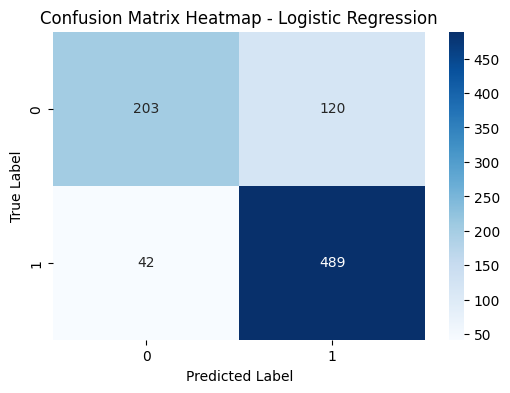

In [29]:
logistic_cm = plot_confusion_matrix(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression"
)

### Interpretation of Logistic Regression Confusion Matrix

Based on the results, we can see that the model has **correctly predicted 203 loan applications as rejected**, which are True Negatives. This implies that the model has correctly identified applicants who should not receive loan approval. In addition, the model has **correctly predicted 489 loan applications as approved**, which are True Positives. This implies that the model performs particularly well in identifying applicants who qualify to receive loan approval.

On the other hand, the results indicate that the model has also experienced some classification errors. The model has **experienced 120 False Positives**, meaning that the model has predicted some loan applications to be approved when in fact they are not. This implies that the model may be overly optimistic when evaluating loan applications, meaning that the model may end up approving applicants who should not receive loan approval. The high number of false positives can also be affected by the class distribution of the dataset, where there are more cases of approved loans. The fact that the dataset contains many cases of approved loans can result in the model being biased towards predicting approved loans, hence the high number of false positives. In addition, the model has **experienced 42 False Negatives**, meaning that the model has predicted some applicants who should receive loan approval to be rejected. This number is low compared to the number of false positives, indicating that the model is less likely to reject qualified applicants.

The above results show that while Logistic Regression performs well in identifying approved loan applications, it also poses a risk of incorrectly approving rejected applicants. This is a clear indication that the decision boundary of the model is slightly biased towards approval, resulting in a higher number of false positives than false negatives. Some of these errors may be due to the complex relationships between financial attributes that cannot be easily modeled using a linear classification model.

3. ROC Curve

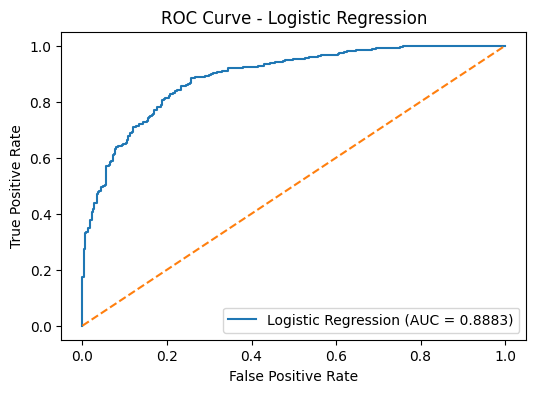

In [31]:
logistic_auc = plot_roc(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression"
)

### Interpretation of the ROC Curve for Logistic Regression

The curve is well above the diagonal reference line, This means that the model is performing much better than a random classification model.

The Model has an **AUC value of around 0.888** suggests that the model is performing well in distinguishing between the two classes. In practical terms, if we randomly select an approved loan application and a rejected loan application, the model will assign a higher probability of approval to the approved application almost 88.8% of the time.

The steep increase of the curve on the left side of the plot means that the model is able to achieve a higher true positive rate while keeping the false positive rate low. This means that the model is able to successfully identify a large number of approved loans without increasing the number of false approvals.

As the curve moves to the upper right area of the plot, the true positive rate continues to rise but at the cost of a higher false positive rate. This is because there is a need to balance the true positives in approving the loan with the false positives in the approval of the loan. In the case of predicting the loan approval, it would therefore enable the decision-maker to control how conservative or permissive the approval process should be.

Overall, the ROC curve has proven the significance of the Logistic Regression model in recognizing the patterns of the financial attributes of the applicants and has a high level of discrimination in the approved or rejected loan applications.

4. Cross-Validation

In [32]:
logistic_cv_scores = evaluate_cross_validation(
    logistic_model,
    X,
    y,
    "Logistic Regression",
    cv=5
)

===== Logistic Regression Cross-Validation (5-Fold) =====
Cross-validation scores: [0.82084309 0.81615925 0.80210773 0.77517564 0.79132474]
Mean CV accuracy: 0.8011220901021605
Standard deviation: 0.016644589358825384


### Interpretation of Logistic Regression Cross-Validation Results

The results obtained from the cross-validation process show that the Logistic Regression model has an accuracy between **0.775 and 0.821**. These results indicate that the model performs consistently across different subsets of the dataset.

The fact that the model has an **average accuracy of around 0.801** implies that the model is able to perform consistently when trained on different portions of the dataset. The results are also similar to those obtained earlier, where the model achieved an accuracy of around 81%. This suggests that the model is able to perform well without relying on a single train-test split.

The results also show that **the standard deviation is around 0.0166**, which is relatively small, and this implies that the performance of the model does not vary significantly across the different folds. This suggests that the Logistic Regression model is relatively stable and that its predictions are not highly affected by variations in the training data.

## Evaluation of SVM

## Evaluation of Random Forest

# **4. Comparative Analysis & Interpretation**